In [1]:
# Get data

import pandas as pd
import numpy as np

df = pd.read_csv('Chicago_data.csv')
df.head()

,School ID,Name of School,"Elementary, Middle, or High School",Street Address,City,State,ZIP Code,Phone Number,Link,Network Manager,...,RCDTS Code,X_COORDINATE,Y_COORDINATE,Latitude,Longitude,Community Area Number,Community Area Name,Ward,Police District,Location
0,610038,Abraham Lincoln Elementary School,ES,615 W Kemper Pl,Chicago,IL,60614,(773) 534-5720,http://schoolreports.cps.edu/SchoolProgressRep...,Fullerton Elementary Network,...,150000000000000,1171699.458,1915829.428,41.924497,-87.644522,7,LINCOLN PARK,43,18,"(41.92449696, -87.64452163)"
1,610281,Adam Clayton Powell Paideia Community Academy ...,ES,7511 S South Shore Dr,Chicago,IL,60649,(773) 535-6650,http://schoolreports.cps.edu/SchoolProgressRep...,Skyway Elementary Network,...,150000000000000,1196129.985,1856209.466,41.760324,-87.556736,43,SOUTH SHORE,7,4,"(41.76032435, -87.55673627)"
2,610185,Adlai E Stevenson Elementary School,ES,8010 S Kostner Ave,Chicago,IL,60652,(773) 535-2280,http://schoolreports.cps.edu/SchoolProgressRep...,Midway Elementary Network,...,150000000000000,1148427.165,1851012.215,41.747111,-87.731702,70,ASHBURN,13,8,"(41.74711093, -87.73170248)"
3,609993,Agustin Lara Elementary Academy,ES,4619 S Wolcott Ave,Chicago,IL,60609,(773) 535-4389,http://schoolreports.cps.edu/SchoolProgressRep...,Pershing Elementary Network,...,150000000000000,1164504.290,1873959.199,41.809757,-87.672145,61,NEW CITY,20,9,"(41.8097569, -87.6721446)"
4,610513,Air Force Academy High School,HS,3630 S Wells St,Chicago,IL,60609,(773) 535-1590,http://schoolreports.cps.edu/SchoolProgressRep...,Southwest Side High School Network,...,150000000000000,1175177.622,1880745.126,41.828146,-87.632794,34,ARMOUR SQUARE,11,9,"(41.82814609, -87.63279369)"


In [2]:
# Check the columns

df.columns.tolist()

['School ID',
 'Name of School',
 'Elementary, Middle, or High School',
 'Street Address',
 'City',
 'State',
 'ZIP Code',
 'Phone Number',
 'Link ',
 'Network Manager',
 'Collaborative Name',
 'Adequate Yearly Progress Made? ',
 'Track Schedule',
 'CPS Performance Policy Status',
 'CPS Performance Policy Level',
 'Healthy Schools Certified?',
 'Safety Icon ',
 'Safety Score',
 'Family Involvement Icon',
 'Family Involvement Score',
 'Environment Icon ',
 'Environment Score',
 'Instruction Icon ',
 'Instruction Score',
 'Leaders Icon ',
 'Leaders Score ',
 'Teachers Icon ',
 'Teachers Score',
 'Parent Engagement Icon ',
 'Parent Engagement Score',
 'Parent Environment Icon',
 'Parent Environment Score',
 'Average Student Attendance',
 'Rate of Misconducts (per 100 students) ',
 'Average Teacher Attendance',
 'Individualized Education Program Compliance Rate ',
 'Pk-2 Literacy %',
 'Pk-2 Math %',
 'Gr3-5 Grade Level Math %',
 'Gr3-5 Grade Level Read % ',
 'Gr3-5 Keep Pace Read %',
 'Gr3

In [3]:
# Delete space at the end of the column names

df.columns = df.columns.str.strip()
df.columns.tolist()

['School ID',
 'Name of School',
 'Elementary, Middle, or High School',
 'Street Address',
 'City',
 'State',
 'ZIP Code',
 'Phone Number',
 'Link',
 'Network Manager',
 'Collaborative Name',
 'Adequate Yearly Progress Made?',
 'Track Schedule',
 'CPS Performance Policy Status',
 'CPS Performance Policy Level',
 'Healthy Schools Certified?',
 'Safety Icon',
 'Safety Score',
 'Family Involvement Icon',
 'Family Involvement Score',
 'Environment Icon',
 'Environment Score',
 'Instruction Icon',
 'Instruction Score',
 'Leaders Icon',
 'Leaders Score',
 'Teachers Icon',
 'Teachers Score',
 'Parent Engagement Icon',
 'Parent Engagement Score',
 'Parent Environment Icon',
 'Parent Environment Score',
 'Average Student Attendance',
 'Rate of Misconducts (per 100 students)',
 'Average Teacher Attendance',
 'Individualized Education Program Compliance Rate',
 'Pk-2 Literacy %',
 'Pk-2 Math %',
 'Gr3-5 Grade Level Math %',
 'Gr3-5 Grade Level Read %',
 'Gr3-5 Keep Pace Read %',
 'Gr3-5 Keep Pace

In [4]:
# Get high school data only

df_hs = df[df['Elementary, Middle, or High School'] == 'HS'].reset_index(drop=True)
print(f'The size of this date is {df_hs.shape}')

The size of this date is (93, 79)


In [5]:
# Select necessary variables

df_hs_var = df_hs[['9th Grade EXPLORE (2010)', '10th Grade PLAN (2010)', '11th Grade Average ACT (2011)', 'College Enrollment Rate %']]

# Drop NAN

df_hs_var = df_hs_var.replace('NDA',np.nan, regex=True)
df_hs_var = df_hs_var.dropna().reset_index(drop=True)
print(f'The data size after clearning NAN is {df_hs_var.shape}')



The data size after clearning NAN is (76, 4)


In [6]:
# Check data types

df_hs_var.dtypes

,0
9th Grade EXPLORE (2010),object
10th Grade PLAN (2010),object
11th Grade Average ACT (2011),object
College Enrollment Rate %,object


In [7]:
# Change the data type to float for statistical analyses

df_hs_var = df_hs_var.astype(float)
df_hs_var.dtypes

,0
9th Grade EXPLORE (2010),float64
10th Grade PLAN (2010),float64
11th Grade Average ACT (2011),float64
College Enrollment Rate %,float64


In [8]:
# Generate descriptive statistics

df_hs_var.describe().round(2)

,9th Grade EXPLORE (2010),10th Grade PLAN (2010),11th Grade Average ACT (2011),College Enrollment Rate %
count,76.00,76.00,76.00,76.00
mean,14.07,15.09,16.82,56.90
std,2.44,2.49,3.19,15.09
min,11.00,12.40,13.50,31.30
25%,12.38,13.50,14.80,45.18
50%,13.40,14.25,15.75,53.45
75%,14.60,15.82,17.50,64.40
max,22.20,24.70,28.80,90.70


In [9]:
# Regression analysis

from sklearn.linear_model import LinearRegression

lm = LinearRegression()

X = df_hs_var[['9th Grade EXPLORE (2010)', '10th Grade PLAN (2010)', '11th Grade Average ACT (2011)']]
Y = df_hs_var['College Enrollment Rate %']
lm.fit(X, Y)
print(f'The R-square is: {lm.score(X, Y):.2f}')

The R-square is: 0.67


Text(0, 0.5, 'College Enrollment Rate %')

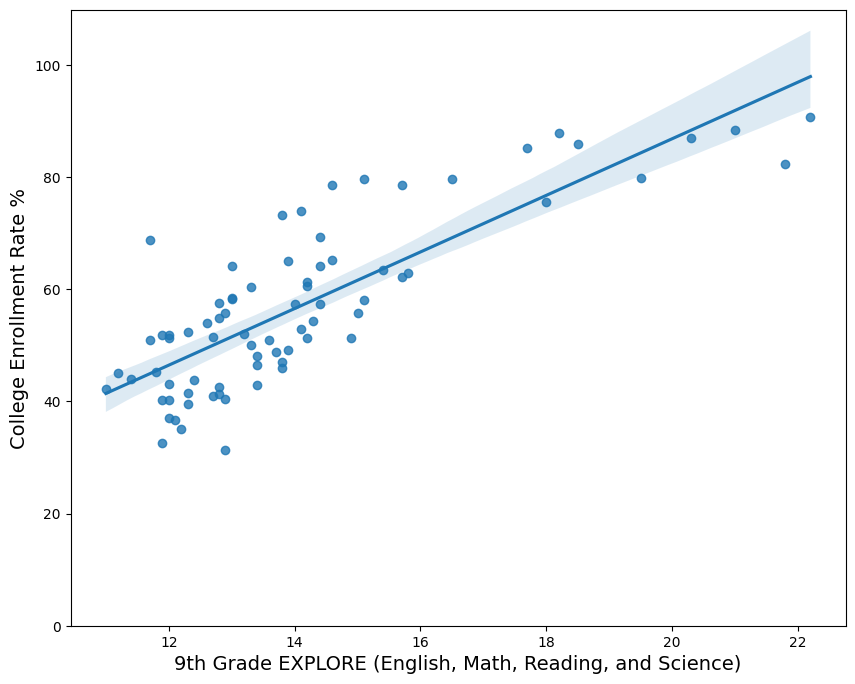

In [11]:
import seaborn as sns

%matplotlib inline

import matplotlib.pyplot as plt

width = 10
height = 8
plt.figure(figsize=(width, height))
sns.regplot(x='9th Grade EXPLORE (2010)', y='College Enrollment Rate %', data=df_hs_var)
plt.ylim(0,)
plt.xlabel('9th Grade EXPLORE (English, Math, Reading, and Science)', fontsize=14)
plt.ylabel('College Enrollment Rate %', fontsize=14)

Text(0, 0.5, 'College Enrollment Rate %')

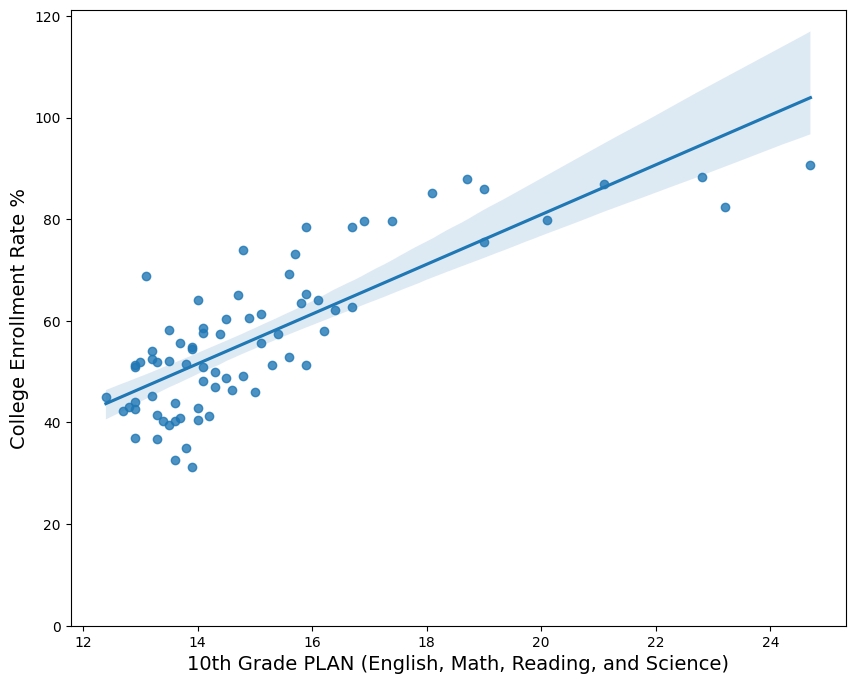

In [12]:
plt.figure(figsize=(width, height))
sns.regplot(x='10th Grade PLAN (2010)', y='College Enrollment Rate %', data=df_hs_var)
plt.ylim(0,)
plt.xlabel('10th Grade PLAN (English, Math, Reading, and Science)', fontsize=14)
plt.ylabel('College Enrollment Rate %', fontsize=14)

Text(0, 0.5, 'College Enrollment Rate %')

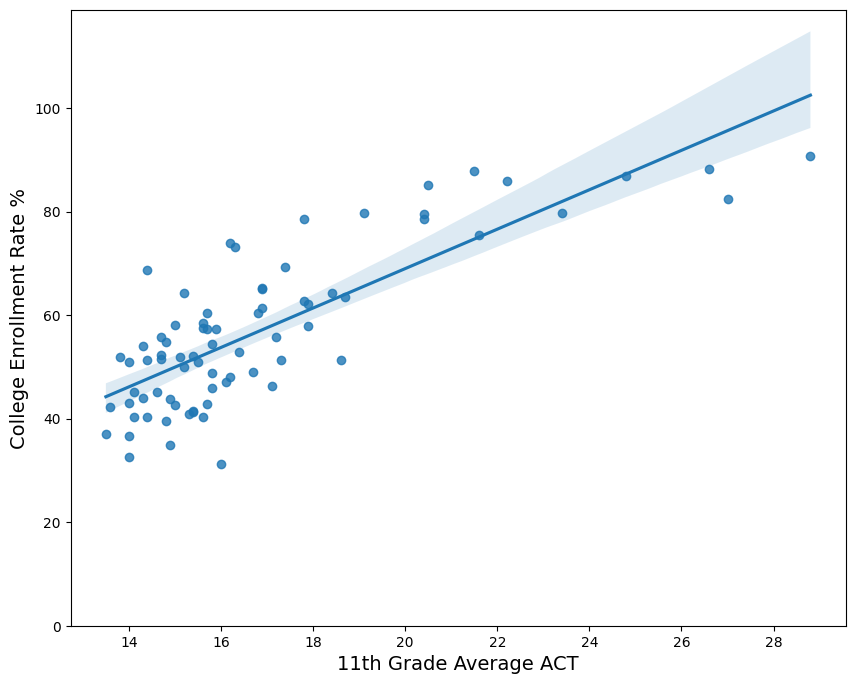

In [13]:
plt.figure(figsize=(width, height))
sns.regplot(x='11th Grade Average ACT (2011)', y='College Enrollment Rate %', data=df_hs_var)
plt.ylim(0,)
plt.xlabel('11th Grade Average ACT', fontsize=14)
plt.ylabel('College Enrollment Rate %', fontsize=14)